In [1]:
# ============================================================
# SWYNEX TECHNOLOGIES - TASK 1
# NETFLIX DATA CLEANING & PREPARATION
# ============================================================

# 1. IMPORT LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files

print("=" * 60)
print("SWYNEX TECHNOLOGIES")
print("NETFLIX DATA CLEANING & PREPARATION")
print("=" * 60)



SWYNEX TECHNOLOGIES
NETFLIX DATA CLEANING & PREPARATION


In [2]:

# ============================================================
# 2. UPLOAD DATASET
# ============================================================

print("\nUpload netflix_titles.csv")

uploaded = files.upload()

file_name = list(uploaded.keys())[0]

df = pd.read_csv(file_name)

print("\nDataset loaded successfully!")



Upload netflix_titles.csv


Saving netflix_titles.csv to netflix_titles (1).csv

Dataset loaded successfully!


In [3]:
# ============================================================
# 3. INITIAL DATASET INSPECTION
# ============================================================

print("\n" + "=" * 60)
print("1. DATASET OVERVIEW")
print("=" * 60)

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nFirst 5 records:")
display(df.head())

print("\nColumn names:")
print(df.columns.tolist())



1. DATASET OVERVIEW
Rows: 8807
Columns: 12

First 5 records:


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...



Column names:
['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description']


In [4]:
# ============================================================
# 4. DATA TYPES
# ============================================================

print("\n" + "=" * 60)
print("2. DATA TYPES")
print("=" * 60)

print(df.dtypes)



2. DATA TYPES
show_id         object
type            object
title           object
director        object
cast            object
country         object
date_added      object
release_year     int64
rating          object
duration        object
listed_in       object
description     object
dtype: object


In [5]:
# ============================================================
# 5. MISSING VALUE ANALYSIS
# ============================================================

print("\n" + "=" * 60)
print("3. MISSING VALUE ANALYSIS")
print("=" * 60)

missing = df.isnull().sum()

missing_percent = (
    df.isnull().sum() / len(df) * 100
).round(2)

missing_report = pd.DataFrame({
    "Missing Values": missing,
    "Percentage": missing_percent
})

missing_report = missing_report[
    missing_report["Missing Values"] > 0
].sort_values(
    "Missing Values",
    ascending=False
)

display(missing_report)



3. MISSING VALUE ANALYSIS


,Missing Values,Percentage
director,2634,29.91
country,831,9.44
cast,825,9.37
date_added,10,0.11
rating,4,0.05
duration,3,0.03


In [6]:
# ============================================================
# 6. DUPLICATE ANALYSIS
# ============================================================

print("\n" + "=" * 60)
print("4. DUPLICATE ANALYSIS")
print("=" * 60)

duplicates = df.duplicated().sum()

print("Duplicate records found:", duplicates)



4. DUPLICATE ANALYSIS
Duplicate records found: 0


In [7]:
# ============================================================
# 7. CREATE CLEANING COPY
# ============================================================

clean_df = df.copy()

In [8]:
# ============================================================
# 8. REMOVE DUPLICATES
# ============================================================

clean_df = clean_df.drop_duplicates()

print("\nDuplicates removed.")
print("Rows after duplicate removal:", len(clean_df))


Duplicates removed.
Rows after duplicate removal: 8807


In [9]:
# ============================================================
# 9. STANDARDIZE TEXT COLUMNS
# ============================================================

print("\n" + "=" * 60)
print("5. TEXT STANDARDIZATION")
print("=" * 60)

text_columns = clean_df.select_dtypes(
    include="object"
).columns

for column in text_columns:

    clean_df[column] = (
        clean_df[column]
        .astype("string")
        .str.strip()
    )

print("Leading and trailing spaces standardized.")




5. TEXT STANDARDIZATION
Leading and trailing spaces standardized.


In [10]:
# ============================================================
# 10. HANDLE MISSING VALUES
# ============================================================

print("\n" + "=" * 60)
print("6. MISSING VALUE TREATMENT")
print("=" * 60)

# Columns where missing information can be represented
# with a meaningful category
category_columns = [
    "director",
    "cast",
    "country",
    "rating",
    "duration"
]

for column in category_columns:

    if column in clean_df.columns:

        clean_df[column] = (
            clean_df[column]
            .fillna("Unknown")
        )

        print(
            column,
            "-> missing values replaced with 'Unknown'"
        )


6. MISSING VALUE TREATMENT
director -> missing values replaced with 'Unknown'
cast -> missing values replaced with 'Unknown'
country -> missing values replaced with 'Unknown'
rating -> missing values replaced with 'Unknown'
duration -> missing values replaced with 'Unknown'


In [11]:
# ============================================================
# 11. CONVERT DATE COLUMN
# ============================================================

print("\n" + "=" * 60)
print("7. DATE TYPE CORRECTION")
print("=" * 60)

clean_df["date_added"] = pd.to_datetime(
    clean_df["date_added"],
    errors="coerce"
)

print(
    "date_added data type:",
    clean_df["date_added"].dtype
)




7. DATE TYPE CORRECTION
date_added data type: datetime64[ns]


In [12]:
# ============================================================
# 12. STANDARDIZE CATEGORIES
# ============================================================

print("\n" + "=" * 60)
print("8. CATEGORY STANDARDIZATION")
print("=" * 60)

clean_df["type"] = (
    clean_df["type"]
    .str.strip()
    .str.title()
)

clean_df["rating"] = (
    clean_df["rating"]
    .str.strip()
    .str.upper()
)

print("Type and rating categories standardized.")




8. CATEGORY STANDARDIZATION
Type and rating categories standardized.


In [13]:
# ============================================================
# 13. VALIDATE NUMERICAL / CATEGORICAL VALUES
# ============================================================

print("\n" + "=" * 60)
print("9. DATA VALIDATION")
print("=" * 60)

print("\nContent types:")
print(
    clean_df["type"].value_counts()
)

print("\nInvalid content types:")

valid_types = [
    "Movie",
    "Tv Show"
]

invalid_types = clean_df[
    ~clean_df["type"].isin(valid_types)
]

print(
    len(invalid_types)
)



9. DATA VALIDATION

Content types:
type
Movie      6131
Tv Show    2676
Name: count, dtype: Int64

Invalid content types:
0


In [14]:
# ============================================================
# 14. CHECK DUPLICATES AGAIN
# ============================================================

print("\n" + "=" * 60)
print("10. FINAL DUPLICATE CHECK")
print("=" * 60)

print(
    "Remaining duplicate records:",
    clean_df.duplicated().sum()
)



10. FINAL DUPLICATE CHECK
Remaining duplicate records: 0


In [15]:
# ============================================================
# 15. FINAL MISSING VALUE CHECK
# ============================================================

print("\n" + "=" * 60)
print("11. FINAL MISSING VALUE CHECK")
print("=" * 60)

final_missing = clean_df.isnull().sum()

final_missing = final_missing[
    final_missing > 0
]

if len(final_missing) == 0:

    print("✓ No missing values remain.")

else:

    display(final_missing)


11. FINAL MISSING VALUE CHECK


,0
date_added,10


In [16]:
# ============================================================
# 16. BEFORE VS AFTER COMPARISON
# ============================================================

print("\n" + "=" * 60)
print("12. BEFORE VS AFTER")
print("=" * 60)

comparison = pd.DataFrame({
    "Metric": [
        "Total Rows",
        "Total Columns",
        "Duplicate Rows",
        "Missing Values"
    ],

    "Before Cleaning": [
        df.shape[0],
        df.shape[1],
        df.duplicated().sum(),
        df.isnull().sum().sum()
    ],

    "After Cleaning": [
        clean_df.shape[0],
        clean_df.shape[1],
        clean_df.duplicated().sum(),
        clean_df.isnull().sum().sum()
    ]
})

display(comparison)


12. BEFORE VS AFTER


,Metric,Before Cleaning,After Cleaning
0,Total Rows,8807,8807
1,Total Columns,12,12
2,Duplicate Rows,0,0
3,Missing Values,4307,10



13. DATA QUALITY VISUALIZATION


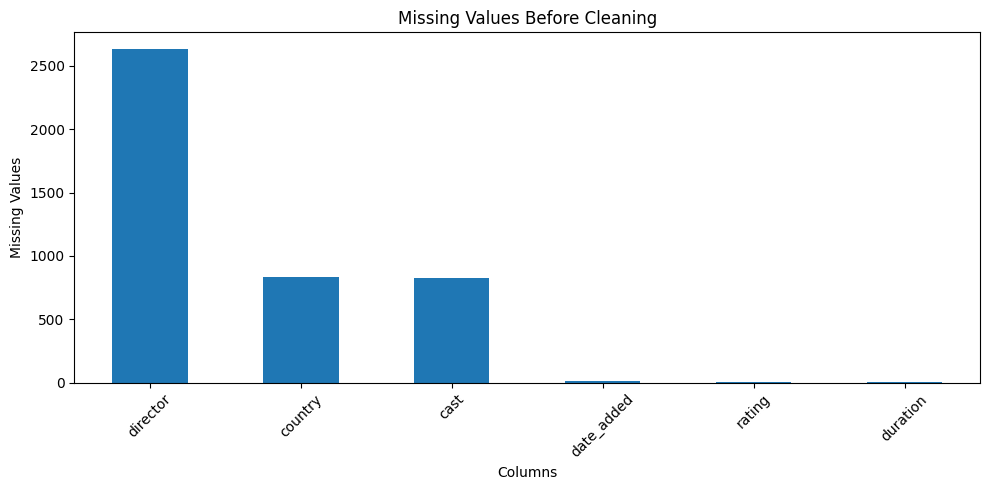

In [17]:
# ============================================================
# 17. DATA QUALITY VISUALIZATION
# ============================================================

print("\n" + "=" * 60)
print("13. DATA QUALITY VISUALIZATION")
print("=" * 60)

missing_before = (
    df.isnull().sum()
    .sort_values(ascending=False)
)

missing_before = missing_before[
    missing_before > 0
]

if len(missing_before) > 0:

    plt.figure(figsize=(10, 5))

    missing_before.plot(
        kind="bar"
    )

    plt.title(
        "Missing Values Before Cleaning"
    )

    plt.xlabel("Columns")
    plt.ylabel("Missing Values")

    plt.xticks(rotation=45)

    plt.tight_layout()

    plt.show()

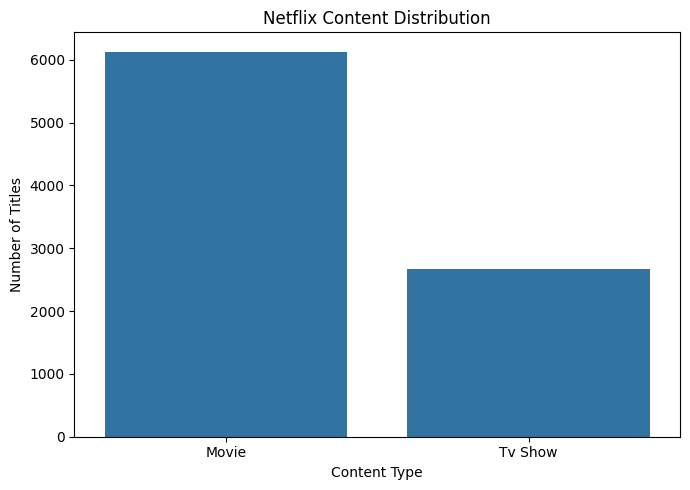

In [18]:
# ============================================================
# 18. CONTENT TYPE VISUALIZATION
# ============================================================

plt.figure(figsize=(7, 5))

sns.countplot(
    data=clean_df,
    x="type"
)

plt.title(
    "Netflix Content Distribution"
)

plt.xlabel("Content Type")
plt.ylabel("Number of Titles")

plt.tight_layout()

plt.show()


In [19]:
# ============================================================
# 19. FINAL DATASET PREVIEW
# ============================================================

print("\n" + "=" * 60)
print("14. CLEANED DATASET")
print("=" * 60)

display(clean_df.head(10))



14. CLEANED DATASET


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,Tv Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,Tv Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,Tv Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,Tv Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
5,s6,Tv Show,Midnight Mass,Mike Flanagan,"Kate Siegel, Zach Gilford, Hamish Linklater, H...",Unknown,2021-09-24,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries",The arrival of a charismatic young priest brin...
6,s7,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",Unknown,2021-09-24,2021,PG,91 min,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...",2021-09-24,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s..."
8,s9,Tv Show,The Great British Baking Show,Andy Devonshire,"Mel Giedroyc, Sue Perkins, Mary Berry, Paul Ho...",United Kingdom,2021-09-24,2021,TV-14,9 Seasons,"British TV Shows, Reality TV",A talented batch of amateur bakers face off in...
9,s10,Movie,The Starling,Theodore Melfi,"Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...",United States,2021-09-24,2021,PG-13,104 min,"Comedies, Dramas",A woman adjusting to life after a loss contend...


In [20]:
# ============================================================
# 20. FINAL DATASET INFORMATION
# ============================================================

print("\n" + "=" * 60)
print("15. FINAL DATA QUALITY CHECK")
print("=" * 60)

print("Rows:", clean_df.shape[0])
print("Columns:", clean_df.shape[1])

print(
    "Missing values:",
    clean_df.isnull().sum().sum()
)

print(
    "Duplicate records:",
    clean_df.duplicated().sum()
)

print("\nFinal data types:")
print(clean_df.dtypes)



15. FINAL DATA QUALITY CHECK
Rows: 8807
Columns: 12
Missing values: 10
Duplicate records: 0

Final data types:
show_id         string[python]
type            string[python]
title           string[python]
director        string[python]
cast            string[python]
country         string[python]
date_added      datetime64[ns]
release_year             int64
rating          string[python]
duration        string[python]
listed_in       string[python]
description     string[python]
dtype: object


In [21]:
# ============================================================
# 21. EXPORT CLEANED DATASET
# ============================================================

cleaned_file = "SWYNEX_cleaned_netflix_dataset.csv"

clean_df.to_csv(
    cleaned_file,
    index=False
)

print("\n✓ Cleaned dataset saved as:")
print(cleaned_file)



✓ Cleaned dataset saved as:
SWYNEX_cleaned_netflix_dataset.csv


In [22]:
# ============================================================
# 22. EXPORT QUALITY REPORT
# ============================================================

quality_report = pd.DataFrame({
    "Column": clean_df.columns,
    "Data Type": clean_df.dtypes.astype(str),
    "Missing Values": clean_df.isnull().sum(),
    "Unique Values": clean_df.nunique()
})

quality_report.to_csv(
    "SWYNEX_final_data_quality_report.csv",
    index=False
)

comparison.to_csv(
    "SWYNEX_before_after_comparison.csv",
    index=False
)

print("\n✓ Quality reports created.")




✓ Quality reports created.


In [23]:
# ============================================================
# 23. DOWNLOAD FILES
# ============================================================

print("\n" + "=" * 60)
print("PROJECT COMPLETED")
print("=" * 60)

print("""
Generated files:

1. SWYNEX_cleaned_netflix_dataset.csv
2. SWYNEX_final_data_quality_report.csv
3. SWYNEX_before_after_comparison.csv

These files can be uploaded to your GitHub repository.
""")

files.download(
    "SWYNEX_cleaned_netflix_dataset.csv"
)


PROJECT COMPLETED

Generated files:

1. SWYNEX_cleaned_netflix_dataset.csv
2. SWYNEX_final_data_quality_report.csv
3. SWYNEX_before_after_comparison.csv

These files can be uploaded to your GitHub repository.



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>